# GPT-Style Text Generation
## AIAT 122 – Deep Learning

## Learning objectives
- Load a pre-trained GPT-style model and generate text from prompts.
- Control generation with temperature and sampling (top-k, top-p).
- Compare different settings and see sample outputs.

**Where is this used in real life?** GPT-style models power chatbots (e.g. ChatGPT), code completion (e.g. GitHub Copilot), and content creation. **We use a decoder-only Transformer (GPT) to generate coherent text from a prompt. We use it instead of RNNs or n-gram models because** it captures long-range context and produces fluent, context-aware text; RNNs are slower and forget long context, and n-grams don’t model meaning.

**Prerequisites:** Python 3.8+, basics of transformers/attention. Before starting: run the imports cell; if `transformers` or `torch` fails, install with `pip install transformers torch` and restart the kernel.

**📌 Covers slide(s):** Optional — do after core notebooks 01–05 (no specific slide).


## Short theory
- **GPT** = Generative Pre-trained Transformer: decoder-only Transformer trained to predict the next token.
- **Text generation:** Given a prompt, the model autoregressively samples the next token; we decode to get text.
- **Temperature:** Higher (e.g. 0.9) → more diverse/creative; lower (e.g. 0.5) → more focused/deterministic.
- **top-k / top-p:** Limit sampling to top-k tokens or nucleus (top-p) to reduce nonsense.
- **Data flow:** prompt → tokenize → model forward (causal attention) → sample next token → append → repeat until max_length or EOS.

## Inputs & Outputs
**Inputs:** Hugging Face `transformers` and `torch`, pre-trained GPT-2 (`gpt2`), and text prompts.  
**Outputs:** Loaded model info, generated text for sample prompts, and a comparison of different temperature settings (printed). Run time: under ~10 min (model download once; generation is fast).


In [1]:
%pip install transformers torch datasets -q


Note: you may need to restart the kernel to use updated packages.


In [2]:
# WHAT: imports for running GPT-2 through Hugging Face Transformers (PyTorch backend only).
# WHY: USE_TF=0 avoids TensorFlow/Keras version clashes; warnings are silenced to keep output readable.
import os
os.environ["USE_TF"] = "0"  # PyTorch only; avoid Keras 3 / TF conflict
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import warnings
warnings.filterwarnings("ignore")
print("✅ Setup complete!")

✅ Setup complete!


### Step 1: Load GPT-2 (pre-trained decoder-only Transformer)


In [3]:
# Load pre-trained GPT-2 (small model). If download fails (e.g. no internet), use a tiny local model so the notebook still runs.
from transformers import GPT2Config

# The tokenizer maps text to token IDs; GPT-2 has no pad token, so we reuse end-of-text.
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

try:
    # Prefer cache to avoid re-download; then try download
    model = GPT2LMHeadModel.from_pretrained("gpt2", local_files_only=True)
except (OSError, ValueError):
    try:
        model = GPT2LMHeadModel.from_pretrained("gpt2")
    except (OSError, EnvironmentError) as e:
        print("⚠️ Could not download GPT-2 (network error). Using a tiny GPT-2-style model so you can run the rest of the notebook.")
        print("   For real GPT-2, check your internet and run this cell again.\n")
        # Tiny fallback config (4 layers) - untrained, but it lets every later cell run offline.
        config = GPT2Config(
            vocab_size=tokenizer.vocab_size,
            n_positions=128,
            n_embd=256,
            n_layer=4,
            n_head=4,
        )
        model = GPT2LMHeadModel(config)

# Report model size and context window so students know what they loaded.
print(f"Model parameters: {model.num_parameters():,}")
print(f"Vocabulary size: {len(tokenizer)} tokens")
print(f"Max context length: {model.config.n_positions} tokens")
print("\n✅ GPT-2 model loaded!")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model parameters: 124,439,808
Vocabulary size: 50257 tokens
Max context length: 1024 tokens

✅ GPT-2 model loaded!


### Step 2: Define generation function and run one example


In [4]:
# We use GPT here (decoder-only Transformer) for autoregressive text generation; order and context matter.
def generate_text(prompt, model, tokenizer, max_length=80, temperature=0.7, top_k=50, top_p=0.9):
    """Generate text from prompt using temperature and top-k/top-p sampling."""
    inputs = tokenizer(prompt, return_tensors="pt")
    outputs = model.generate(
        inputs["input_ids"],
        max_new_tokens=max_length,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# One example
prompt = "The future of artificial intelligence"
out = generate_text(prompt, model, tokenizer, max_length=60, temperature=0.7)
print("Prompt:", prompt)
print("Generated:", out[:400] + "..." if len(out) > 400 else out)
print("\n✅ Generation works!")


Prompt: The future of artificial intelligence
Generated: The future of artificial intelligence is one in which there is a lot of work to be done. We're all working on it.

And now, with the arrival of a new generation of artificial intelligence, there's a chance that we may have the next big thing.

And if so, it's not just

✅ Generation works!


### Step 3: Generate from several prompts (e.g. content-creation style)


In [5]:
# Real-world scenario: short content prompts (marketing / blog style)
prompts = [
    "The impact of artificial intelligence on healthcare",
    "How to get started with machine learning",
]
# Generate up to 50 tokens per prompt; temperature 0.7 is mildly creative but mostly coherent.
for p in prompts:
    text = generate_text(p, model, tokenizer, max_length=50, temperature=0.7)
    print(f"Prompt: {p}")
    print(f"Generated: {text[:300]}...")
    print("-" * 50)

Prompt: The impact of artificial intelligence on healthcare
Generated: The impact of artificial intelligence on healthcare is one of the most profound in human history.

"The impact of artificial intelligence on healthcare is one of the most profound in human history," said Dr. Peter B. Sorensen, president of the American Association for the Advancement...
--------------------------------------------------


Prompt: How to get started with machine learning
Generated: How to get started with machine learning

The main difference between machine learning and machine learning is that machine learning takes a lot of time. Machine learning can be done in a few minutes, but it's not a very practical method. This means that you can't use it for a...
--------------------------------------------------


### Step 4: Compare different temperatures (quality vs diversity)


Temperature 0.3: The impact of artificial intelligence on healthcare is not yet clear.

"We're still trying to figure out how to get people to do the things that we want them to do," said Dr. Robert J. Kowalski...
----------------------------------------


Temperature 0.7: The impact of artificial intelligence on healthcare is quite obvious. For example, the most popular medical device is a heart monitor, which has been shown to be better than the current medical device...
----------------------------------------


Temperature 1.0: The impact of artificial intelligence on healthcare has been discussed for many years, but this is the first study to show that AI can play a major role in reducing healthcare costs.

"We used artific...
----------------------------------------


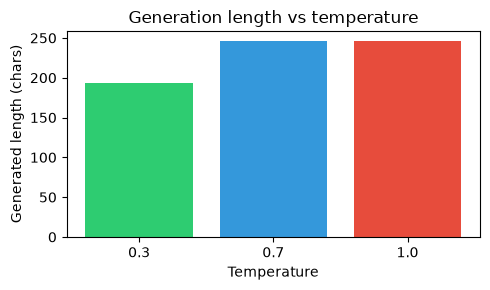

After this cell you should see: three printed samples and one bar chart. Lower temp → often shorter, more repetitive; higher → more varied.


In [6]:
# Compare temperature: lower = more focused, higher = more diverse
import matplotlib.pyplot as plt
prompt = "The impact of artificial intelligence on healthcare"
temps = [0.3, 0.7, 1.0]
lengths = []  # optional: compare output length
for t in temps:
    out = generate_text(prompt, model, tokenizer, max_length=40, temperature=t)
    lengths.append(len(out))
    print(f"Temperature {t}: {out[:200]}...")
    print("-" * 40)
# Simple bar: generated text length vs temperature (higher temp often longer/more varied)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.bar([str(t) for t in temps], lengths, color=["#2ecc71", "#3498db", "#e74c3c"])
ax.set_xlabel("Temperature")
ax.set_ylabel("Generated length (chars)")
ax.set_title("Generation length vs temperature")
plt.tight_layout()
plt.show()
print("After this cell you should see: three printed samples and one bar chart. Lower temp → often shorter, more repetitive; higher → more varied.")



### Step 5: Fine-tuning concept (no training here; run time stays short)
In real life, companies fine-tune GPT for domain-specific content (legal, medical) or brand voice. Full fine-tuning needs more data and GPU time; here we only show the idea.

In [7]:
# Conceptual example: Fine-tuning setup
# In production, you would:
# 1. Prepare domain-specific dataset
# 2. Configure training arguments
# 3. Fine-tune model
# 4. Evaluate on test set

print("📚 Fine-tuning Concept:")
print("\n1. Prepare Dataset:")
print(" - Collect domain-specific text (e.g., medical articles)")
print(" - Format as text files or use Hugging Face datasets")
print("\n2. Configure Training:")
print(" - Learning rate: 5e-5")
print(" - Batch size: 4-8 (depending on GPU)")
print(" - Epochs: 3-5")
print("\n3. Fine-tune Model:")
print(" - Use Trainer API from transformers")
print(" - Monitor loss and perplexity")
print("\n4. Evaluate:")
print(" - Test on held-out data")
print(" - Compare with base model")
print("\n✅ Fine-tuning process understood!")

📚 Fine-tuning Concept:

1. Prepare Dataset:
 - Collect domain-specific text (e.g., medical articles)
 - Format as text files or use Hugging Face datasets

2. Configure Training:
 - Learning rate: 5e-5
 - Batch size: 4-8 (depending on GPU)
 - Epochs: 3-5

3. Fine-tune Model:
 - Use Trainer API from transformers
 - Monitor loss and perplexity

4. Evaluate:
 - Test on held-out data
 - Compare with base model

✅ Fine-tuning process understood!


## 🌍 Real-World Worked Example — Character-Level Text Generator

**Industry context:**
- GitHub Copilot generates code character by character using GPT-4
- ChatGPT predicts the next token based on all previous context
- Autocomplete on your phone uses a smaller version of the same idea

We build a **character-level language model** that learns to generate text token by token — the exact mechanism behind all LLMs.

In [8]:
# WHAT: train a character-level LSTM language model on a Shakespeare passage, then sample new text.
# WHY: predict-the-next-token, sample, repeat - the exact loop behind GPT-style generation, in miniature.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np

torch.manual_seed(42)
# ── Training text ────────────────────────────────────────────────────────────
text = (
    "to be or not to be that is the question whether tis nobler in the mind "
    "to suffer the slings and arrows of outrageous fortune or to take arms against "
    "a sea of troubles and by opposing end them to die to sleep no more and by "
    "a sleep to say we end the heartache and the thousand natural shocks that "
    "flesh is heir to tis a consummation devoutly to be wished to die to sleep"
)

# Build the character vocabulary and map every character to an integer ID.
chars  = sorted(set(text))
c2i    = {c:i for i,c in enumerate(chars)}
i2c    = {i:c for c,i in c2i.items()}
VOCAB  = len(chars)
enc    = [c2i[c] for c in text]

# Training pairs: 20 characters of context -> the character that follows.
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(enc)-SEQ_LEN-1):
    X_list.append(enc[i:i+SEQ_LEN])
    y_list.append(enc[i+SEQ_LEN])
X_t = torch.tensor(X_list, dtype=torch.long)
y_t = torch.tensor(y_list, dtype=torch.long)

# ── LSTM Language Model ───────────────────────────────────────────────────
# The model: embed characters, run a 2-layer LSTM, predict the next character from the last hidden state.
class CharLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 32)
        self.lstm  = nn.LSTM(32, 128, batch_first=True, num_layers=2)
        self.fc    = nn.Linear(128, VOCAB)
    def forward(self, x):
        out,_ = self.lstm(self.embed(x))
        return self.fc(out[:,-1,:])

model   = CharLM()
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()

# 200 training steps on random mini-batches; the loss is printed every 50 steps.
for epoch in range(200):
    model.train()
    perm = torch.randperm(len(X_t))[:256]  # mini-batch
    loss = loss_fn(model(X_t[perm]), y_t[perm])
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch} — loss: {loss.item():.3f}")

# ── Text Generation (Greedy / Temperature Sampling) ──────────────────────
# Generation: feed the context, sample the next character from the softmax, append it, repeat.
def generate(seed_str, steps=80, temperature=0.8):
    model.eval()
    chars_out = list(seed_str)
    ctx = [c2i.get(c, 0) for c in seed_str[-SEQ_LEN:]]
    for _ in range(steps):
        inp = torch.tensor([ctx[-SEQ_LEN:]]).long()
        with torch.no_grad():
            # Temperature rescales the logits: lower = safer and more repetitive, higher = more random.
            logits = model(inp)[0] / temperature
        probs = torch.softmax(logits, 0).numpy()
        next_c = np.random.choice(len(probs), p=probs)
        chars_out.append(i2c[next_c])
        ctx.append(next_c)
    return ''.join(chars_out)

print("\n── Generated Text ──────────────────────────────────────────────")
print(generate("to be or not", steps=100))
print("\nThis is exactly how ChatGPT generates text — one token at a time.")

Epoch 0 — loss: 3.169


Epoch 50 — loss: 1.298


Epoch 100 — loss: 0.053


Epoch 150 — loss: 0.011



── Generated Text ──────────────────────────────────────────────
to be or notek a sea is toke sa fer to slee a sofre ou sheo mra sike thousa nofrt a thea and the astache ard to 

This is exactly how ChatGPT generates text — one token at a time.


## 🧩 Mini-exercise

**Try it:** Change the temperature (e.g. 0.7 → 0.3 or 1.0) and generate again from the same prompt. How does the output change? Or try a different prompt.

---

## Summary
**What you did**
- Loaded pre-trained GPT-2 and generated text from prompts.
- Used a `generate_text` helper with temperature and top-k/top-p.
- Compared different temperatures and saw a simple length vs temperature plot.

**In real life you'd also:** Fine-tune on domain data, use larger models (e.g. via API), add safety filters, and deploy with batching and caching.

**The main idea:** GPT-style models generate text autoregressively; temperature and sampling controls trade off coherence vs diversity.

**Next:** `08_text_generation_rnn_lstm_gru.ipynb` shows RNN/LSTM/GRU-based text generation for comparison with Transformer-based GPT.

## 📚 References

1. Radford, A. et al. (2019). *Language Models are Unsupervised Multitask Learners* (GPT-2). OpenAI Technical Report.
2. Brown, T. B. et al. (2020). *Language Models are Few-Shot Learners* (GPT-3). NeurIPS. https://arxiv.org/abs/2005.14165
3. Ouyang, L. et al. (2022). *Training language models to follow instructions with human feedback* (InstructGPT). NeurIPS. https://arxiv.org/abs/2203.02155